<a href="https://colab.research.google.com/github/macine-git/Introductive-ML-Projects/blob/main/TP2_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PRACTICAL N°2: PROBABILISTIC CLASSIFICATION**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# For dataset manipulation
import pandas as pd

# For logistic regression
import statsmodels.api as sm

## TRAINING: DATA MANIPULATION WITH PANDAS AND NAIVE BAYES CLASSIFICATION

### NumPy and Pandas

We start by a short introduction to Pandas.

With `NumPy`, arrays can have arbitrary dimension, and each dimension is indexed by an integer starting from $0$.

In [ ]:
# A one-dimensional array
one_dim_np = np.array([3, 5, 2])
print(one_dim_np)

# A two-dimensional array
two_dim_np = np.array([[1, 2], [3, 4]])
print(two_dim_np)

[3 5 2]
[[1 2]
 [3 4]]


The elements of an `np.array` can be accessed as follows.

In [ ]:
print(one_dim_np[0]) # The first element
print(two_dim_np[0,1]) # The element at row 0 and column 1

3
2


It is often useful to define arrays which only contain zeros, with `np.zeros()`.

In [ ]:
# One-dimensional array with 5 zeros
zeros_np = np.zeros(5)
print(zeros_np)

# Two-dimensional array, with 2 rows and 3 columns, containing zeros
zeros_np = np.zeros((2,3))
print(zeros_np)

[0. 0. 0. 0. 0.]
[[0. 0. 0.]
 [0. 0. 0.]]


The `pandas` library allows to work with vectors (called Series) and arrays (called DataFrame) whose columns and rows are given names rather than indices.

In [ ]:
# Create a series with index names 'a', 'b', 'c'
test_s = pd.Series({'a':0, 'b':3, 'c':2})
test_s

,0
a,0
b,3
c,2


In [ ]:
# Elements of the Series can be called by their index names
test_s['a']

np.int64(0)

In [ ]:
# Create a DataFrame with column names 'c1', 'c2', 'c3' and row names 'r1', 'r2', 'r3'
row_names = ['r1','r2','r3']
col_names = ['c1','c2','c3']
test_df = pd.DataFrame(index=row_names,columns=col_names)

# Fill with zeros
for c in col_names:
  for r in row_names:
    # The loc function allows to access the elements of DataFrames by row and column names
    test_df.loc[r,c] = 0

test_df

,c1,c2,c3
r1,0,0,0
r2,0,0,0
r3,0,0,0


To define the DataFrame with zeros, a shorter command is as follows.

In [ ]:
test_df = pd.DataFrame(0,index=row_names,columns=col_names)
test_df

,c1,c2,c3
r1,0,0,0
r2,0,0,0
r3,0,0,0


The list of row names and column names are recovered as follows.

In [ ]:
print(test_df.index) # Row names
print(test_df.columns) # Colmun names

Index(['r1', 'r2', 'r3'], dtype='object')
Index(['c1', 'c2', 'c3'], dtype='object')


It is often useful to extract a subset of a DataFrame. There are two different procedures:

* If you want to extract one or several columns, the syntax is as follows.

In [ ]:
# Extract the first column
extracted_df_col_1 = test_df['c1']
extracted_df_col_1

,c1
r1,0
r2,0
r3,0


In [ ]:
# Extract the second and third columns
columns_to_extract = ['c2', 'c3']
extracted_df_col_2 = test_df[columns_to_extract]
extracted_df_col_2

,c2,c3
r1,0,0
r2,0,0
r3,0,0


Notice that if you extract a single column, then you get a Series object, while if you extract several columns you get a DataFrame object.

In [ ]:
print(type(extracted_df_col_1))
print(type(extracted_df_col_2))

<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>


* If you want to also extract rows, use the `loc` function.

In [ ]:
# Extract the first row
extracted_df_row_1 = test_df.loc['r1']
extracted_df_row_1

,r1
c1,0
c2,0
c3,0


In [ ]:
# Extract the first and second rows, and the first and third columns
extracted_df = test_df.loc[['r1','r2'],['c1','c3']]
extracted_df

,c1,c3
r1,0,0
r2,0,0


### Importing data

We will work with the file `p28fake.csv`, which contains, for each student of your class:

*   the origin track (we will call it filiere);
*   the grades in the mandatory courses of semester 1;
*   the choice of the elective course of semester 1.

Note that the grades are **fake**: they have been resampled from a Gaussian distribution with parameters estimated from the true data.

We first create the data set.

In [ ]:
# Put the dataset into a pandas DataFrame
repert='/content/'
dataset = pd.read_table(repert+'p28fake.csv', sep=';', decimal=',')
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   FILIERE  210 non-null    object 
 1   MEDP     210 non-null    float64
 2   CALC     210 non-null    float64
 3   OPTI     210 non-null    float64
 4   OMPM     210 non-null    float64
 5   ENRJ1    210 non-null    float64
 6   ECON1    210 non-null    float64
 7   ISHS     210 non-null    float64
 8   COMM     210 non-null    float64
 9   ELECTIF  210 non-null    object 
dtypes: float64(8), object(2)
memory usage: 16.5+ KB


The DataFrame `dataset` looks like this:

In [ ]:
dataset

,FILIERE,MEDP,CALC,OPTI,OMPM,ENRJ1,ECON1,ISHS,COMM,ELECTIF
0,BCPST,15.4,16.7,11.1,8.0,10.0,20.0,16.6,13.5,IMET
1,MP,12.2,14.0,11.2,9.1,18.6,11.9,14.4,16.8,URBVI
2,MP,16.1,12.4,13.8,5.1,13.3,11.9,12.5,14.4,URBVI
3,MP,18.1,13.9,15.8,8.5,12.3,13.8,14.9,14.4,URBVI
4,MP,19.5,13.0,18.9,12.2,13.2,8.5,17.5,15.0,URBVI
...,...,...,...,...,...,...,...,...,...,...
205,AST,17.1,12.8,14.1,5.0,7.7,12.1,10.7,16.2,URBVI
206,AST,6.3,15.2,11.4,1.6,9.0,6.4,16.2,16.4,URBVI
207,AST,7.7,16.0,8.1,3.5,5.3,11.6,10.7,18.6,IMPAC
208,AST,8.1,12.7,7.9,7.2,7.9,10.4,11.6,18.8,IMPAC


We call `n` the number of students (students with missing data have been removed).

In [ ]:
n = len(dataset)
print("n =", n)

n = 210


As you may observe, `dataset` contains features of two different types: continuous features (with type `float64`), and discrete features (with type `object`). We put the names of the features of each type in two different lists.

In [ ]:
# List of continuous features
continuous_features = dataset.select_dtypes(include=['float64']).columns.tolist()

print("continuous_features = ", continuous_features)

# List of discrete features
discrete_features = dataset.select_dtypes(include=['object']).columns.tolist()

print("discrete_features = ", discrete_features)

continuous_features =  ['MEDP', 'CALC', 'OPTI', 'OMPM', 'ENRJ1', 'ECON1', 'ISHS', 'COMM']
discrete_features =  ['FILIERE', 'ELECTIF']


The function `unique()` allows to display the possible values taken by each discrete feature.

In [ ]:
# List of values of FILIERE
list_filiere = dataset['FILIERE'].unique()
print("Distinct values of FILIERE:", list_filiere)

# List of values of ELECTIF
list_electif = dataset['ELECTIF'].unique()
print("Distinct values of ELECTIF:", list_electif)

Distinct values of FILIERE: ['BCPST' 'MP' 'MPI' 'PC' 'PSI' 'PT' 'AST']
Distinct values of ELECTIF: ['IMET' 'URBVI' 'BIOGC' 'PHEXT' 'IMPAC' 'DDIC' 'ISCV']


For the record, the course's complete names are given as follows.

Mandatory courses:

* MEDP: Modélisation et équations aux dérivées partielles
* CALC: Pratique du calcul pour l'ingénieur
* OPTI: Optimisation
* OMPM: Outils mathématiques pour la mécanique
* ENRJ1: Bases scientifiques pour la transition énergétique 1
* ECON1: Fondamentaux de l'économie pour l'ingénieur 1 : Microéconomie
* ISHS: Introduction aux SHS
* COMM: Communication

Elective courses:

* ISCV: Introduction aux sciences du vivant
* IMET: Introduction à la météorologie
* DDIC: Développement durable : ingénieurs pour un monde complexe et incertain
* IMPAC: Construire et aménager avec l'environnement
* PHEXT: Phénomènes extrêmes en géosciences
* BIOGC: Cycles biogéochimiques dans l'anthropocène
* URBVI: Introduction à l'ingénierie de la ville durable


### Statistics of grades of mandatory courses

We first study the grades of mandatory courses. We compute means and standard deviations for each course.

In [ ]:
for feat in continuous_features:
  print("Mean of", feat, ":", dataset[feat].mean())
  print("Standard deviation of", feat, ":", dataset[feat].std(ddof=0))
  # Using ddof=0 gives the empirical variance as seen in the lecture

Mean of MEDP : 16.032857142857143
Standard deviation of MEDP : 2.599215344707565
Mean of CALC : 13.593333333333335
Standard deviation of CALC : 2.7494334192673455
Mean of OPTI : 14.048571428571428
Standard deviation of OPTI : 2.6251572029377694
Mean of OMPM : 8.33095238095238
Standard deviation of OMPM : 3.324661679546763
Mean of ENRJ1 : 12.28190476190476
Standard deviation of ENRJ1 : 2.7416116550525857
Mean of ECON1 : 12.825714285714286
Standard deviation of ECON1 : 2.0806376573599956
Mean of ISHS : 13.72095238095238
Standard deviation of ISHS : 2.1747991801366173
Mean of COMM : 16.068571428571428
Standard deviation of COMM : 1.629274701952304


We may even plot histograms of grades for each course.

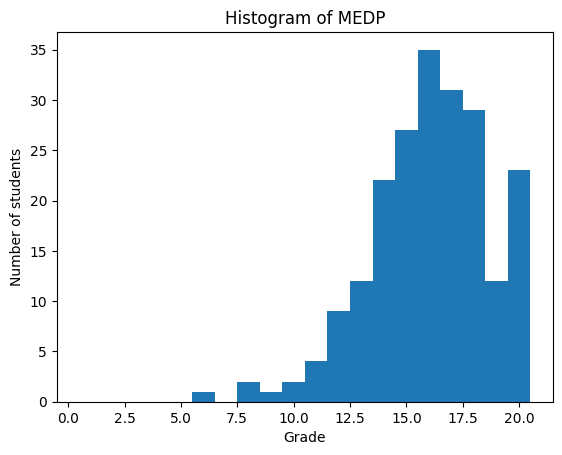

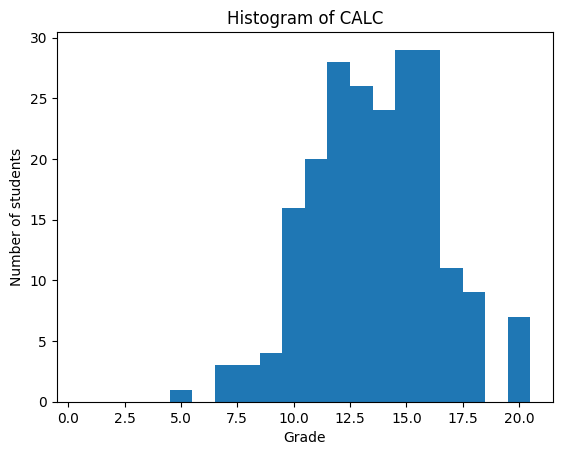

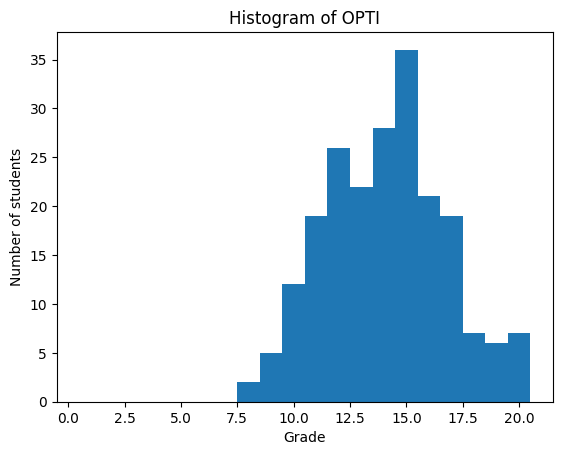

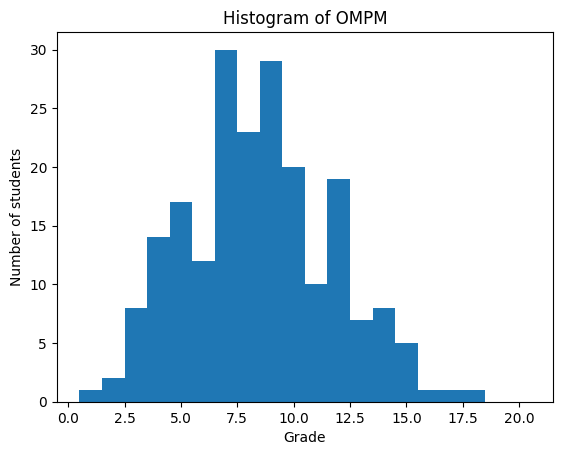

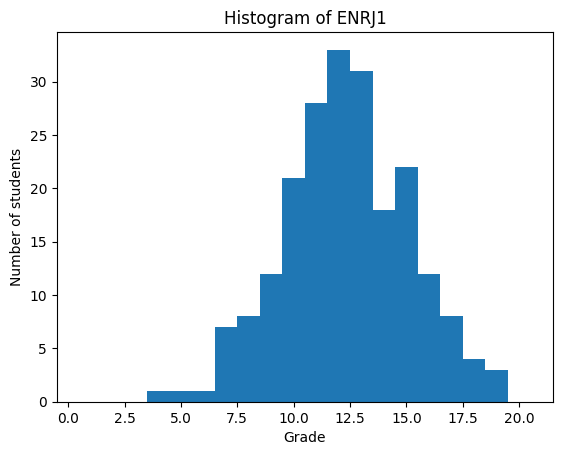

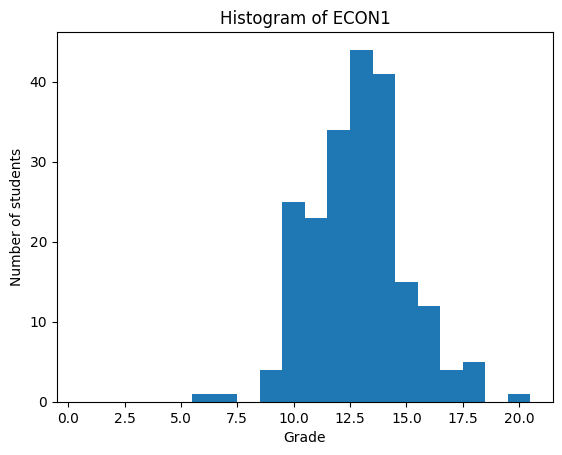

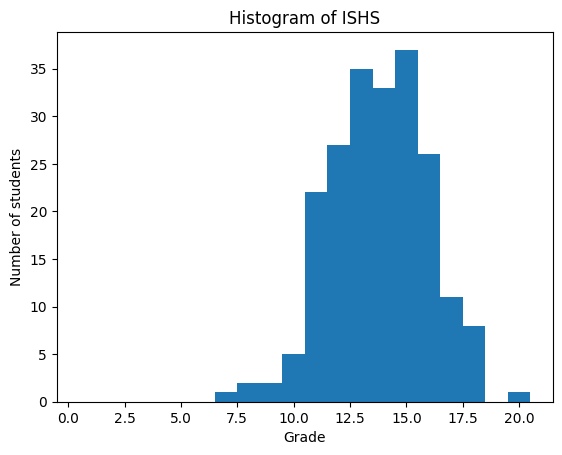

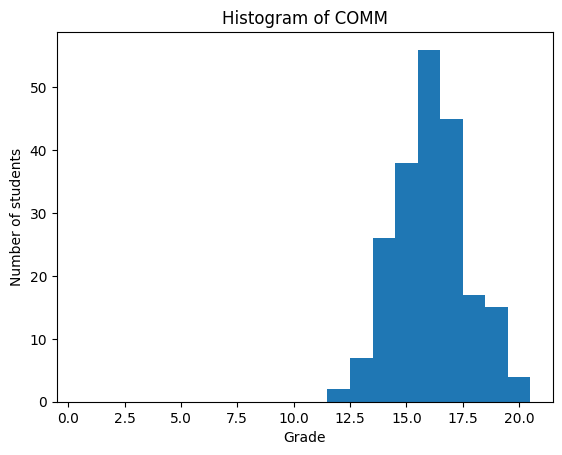

In [ ]:
for feat in continuous_features:
  # bins are the 21 intervals centered around the integers 0, ..., 20
  plt.hist(dataset[feat],bins=np.linspace(.5, 20.5, 21))
  plt.xlabel("Grade")
  plt.ylabel("Number of students")
  plt.title("Histogram of "+feat)
  plt.show()

### Pie chart for elective courses

We now study the choices of elective courses. We fist create and fill a Series indexed by the possible elective courses, which contains the proportion of students having chosen each course.

In [ ]:
list_electif = dataset['ELECTIF'].unique()
p_electif = pd.Series(index=list_electif,dtype=float)

for val in list_electif:
  n_electif = len(dataset[dataset['ELECTIF']==val]) # Number of students choising val
  p_electif[val] = n_electif/n

p_electif

,0
IMET,0.147619
URBVI,0.142857
BIOGC,0.100000
PHEXT,0.138095
IMPAC,0.142857
DDIC,0.185714
ISCV,0.142857


We now use `p_electif` to plot a pie chart.

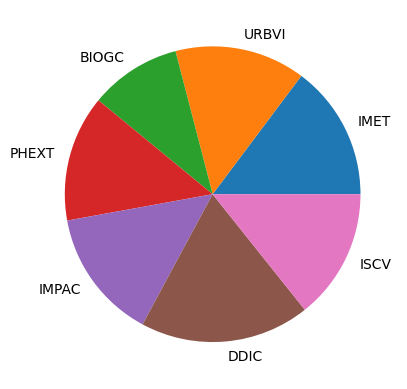

In [ ]:
plt.pie(p_electif, labels=list_electif)
plt.show()

### Naive Bayes classification

We now focus on the application of naive Bayes classification to predict the class `FILIERE` as a function of grades in mandatory courses and choices of elective courses. We first define the training sets `x_train` (with all explanatory variables) and `y_train` (with the explained variables, that is to say the labels).

In [ ]:
# Explained variable
explained_variable = 'FILIERE'
y_train = dataset[explained_variable]

# Explanatory variables
mandatory_courses = continuous_features.copy()
explanatory_variables = mandatory_courses + ['ELECTIF']

x_train = dataset[explanatory_variables]

You may visualise `x_train` and `y_train`.

In [ ]:
x_train

,MEDP,CALC,OPTI,OMPM,ENRJ1,ECON1,ISHS,COMM,ELECTIF
0,15.4,16.7,11.1,8.0,10.0,20.0,16.6,13.5,IMET
1,12.2,14.0,11.2,9.1,18.6,11.9,14.4,16.8,URBVI
2,16.1,12.4,13.8,5.1,13.3,11.9,12.5,14.4,URBVI
3,18.1,13.9,15.8,8.5,12.3,13.8,14.9,14.4,URBVI
4,19.5,13.0,18.9,12.2,13.2,8.5,17.5,15.0,URBVI
...,...,...,...,...,...,...,...,...,...
205,17.1,12.8,14.1,5.0,7.7,12.1,10.7,16.2,URBVI
206,6.3,15.2,11.4,1.6,9.0,6.4,16.2,16.4,URBVI
207,7.7,16.0,8.1,3.5,5.3,11.6,10.7,18.6,IMPAC
208,8.1,12.7,7.9,7.2,7.9,10.4,11.6,18.8,IMPAC


In [ ]:
y_train

,FILIERE
0,BCPST
1,MP
2,MP
3,MP
4,MP
...,...
205,AST
206,AST
207,AST
208,AST


In each class (namely, among the students originating from each filiere), the grades at each mandatory course, and the choice of the elective course, are assumed to be independent random variables.

We choose to model the grades of mandatory courses as Gaussian random variables: for each value $f$ of the variable `FILIERE`, and each mandatory course $m$, we denote by $\mu_{f,m}$ and $\sigma_{f,m}$ the mean and standard deviation of this random variable.

Similarly, for each value $f$ of the variable `FILIERE`, and each elective course $e$, we denote by $p_{f,e}$ the proportion of students from the filiere $f$ having chosen the course $e$.

By Bayes' formula, for a student with grade $x_m \in [0,20]$ at the mandatory course $m$ and having chosen the elective course $e$, the conditional probability to originate from the filiere $f$ is proportional to
$$n_f \times \prod_m \frac{1}{\sqrt{2\pi \sigma_{f,m}^2}} \exp\left(-\frac{(x_m-\mu_{f,m})^2}{2 \sigma_{f,m}^2}\right) \times p_{f,e},$$
where $n_f$ is the overall number of students originating from the filiere $f$.

We must therefore start by estimating the parameters $n_f$, $\mu_{f,m}$, $\sigma_{f,m}$ and $p_{f,e}$. We will put all these parameters in the DataFrame `params`, whose rows are the different values of `FILIERE` and columns are all the parameters to estimate.

In [ ]:
## First define the list of all column names
col_names = ['eff'] # Will contain the number of students originating from each filiere

# Continuous explanatory variables: mandatory courses
for m in mandatory_courses:
  col_names.append('mu_'+m) # Will contain the mean of grades for course m within each filiere
  col_names.append('sigma_'+m) # Will contain the standard deviation of grades for course m within each filiere

# Discrete explanatory variable: elective courses
for e in list_electif:
  col_names.append('p_ELECTIF_'+e) # Will contain the proportion of students from each filiere having chosen course e

## Define the DataFrame param
param = pd.DataFrame(index=list_filiere, columns=col_names)

**Question:** complete the code below to fill the DataFrame `param`.

In [ ]:
for filiere in list_filiere:
  # List of indices of individuals of the training set in filiere
  indices = y_train.index[y_train==filiere]

  # Number of individuals in filiere
  param.loc[filiere,'eff'] = len(indices)

  # Continuous explanatory variables: mandatory courses
  for m in mandatory_courses:
    param.loc[filiere,'mu_'+m] = x_train.loc[indices,m].mean()
    param.loc[filiere,'sigma_'+m] = x_train.loc[indices,m].std(ddof=0)

  # Discrete explanatory variable: elective courses
  for e in list_electif:
    param.loc[filiere,'p_ELECTIF_'+e] = (x_train.loc[indices,'ELECTIF']==e).mean()

param

,eff,mu_MEDP,sigma_MEDP,mu_CALC,sigma_CALC,mu_OPTI,sigma_OPTI,mu_OMPM,sigma_OMPM,mu_ENRJ1,...,sigma_ISHS,mu_COMM,sigma_COMM,p_ELECTIF_IMET,p_ELECTIF_URBVI,p_ELECTIF_BIOGC,p_ELECTIF_PHEXT,p_ELECTIF_IMPAC,p_ELECTIF_DDIC,p_ELECTIF_ISCV
BCPST,1,15.4,0.0,16.7,0.0,11.1,0.0,8.0,0.0,10.0,...,0.0,13.5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
MP,84,16.933333,2.371022,14.034524,2.495877,14.720238,2.481492,8.272619,3.29109,12.45,...,2.19775,16.045238,1.493909,0.154762,0.047619,0.083333,0.178571,0.154762,0.178571,0.202381
MPI,4,17.05,1.836437,14.15,1.537043,12.925,0.990896,5.95,3.65137,12.825,...,2.530193,15.125,1.723913,0.75,0.0,0.25,0.0,0.0,0.0,0.0
PC,37,15.597297,2.109885,13.935135,3.071686,13.637838,2.571502,8.737838,2.634937,12.081081,...,2.401375,16.102703,1.638966,0.081081,0.189189,0.162162,0.162162,0.135135,0.189189,0.081081
PSI,63,15.795238,2.354424,13.284127,2.581141,13.909524,2.677402,8.796825,3.357151,13.004762,...,1.846143,16.214286,1.668842,0.142857,0.206349,0.111111,0.126984,0.126984,0.190476,0.095238
PT,15,14.76,2.023462,11.46,3.142568,13.486667,2.309074,8.0,3.882267,10.493333,...,2.013951,15.326667,1.59811,0.133333,0.2,0.0,0.0,0.133333,0.266667,0.266667
AST,6,11.216667,4.300549,13.0,2.22935,11.283333,2.583548,4.216667,1.778029,8.066667,...,2.271135,17.566667,1.39244,0.0,0.5,0.0,0.0,0.333333,0.166667,0.0


**Question:** complete the code below so that the function `NBClass(x)` takes in input a Series indexed by the list `explanatory_variables`, containing the features of a student, and returns a Series indexed by `list_filiere` containing the conditional probabilities that the student originates from each filiere.

In [ ]:
def NBClass(x):
  probas_unnormalised = pd.Series(0,index=list_filiere,dtype=float)

  for filiere in list_filiere:
    # Number of students in the filiere
    p = param.loc[filiere,'eff']

    # Gaussian densities
    for m in mandatory_courses:
      mu = param.loc[filiere,'mu_'+m]
      sigma = param.loc[filiere,'sigma_'+m]
      p = p*np.exp(-(x[m]-mu)**2/(2*sigma**2))/(np.sqrt(2*np.pi)*sigma)

    # Probability of elective course
    p = p*param.loc[filiere,'p_ELECTIF_'+x['ELECTIF']]

    # Put unnormalised probability in probas_unnormalised
    probas_unnormalised[filiere] = p

  sum_unnormalised = sum(probas_unnormalised)

  return probas_unnormalised/sum_unnormalised

You may test the classification with your own features!

In [ ]:
### User-chosen features

## Mandatory courses

# Modélisation et équations aux dérivées partielles
# Mean=16.3, Stdev=2.7
MEDP = 20

# Pratique du calcul pour l'ingénieur
# Mean=13.9, Stdev=2.7
CALC = 18.5

# Optimisation
# Mean=14.1, Stdev=2.6
OPTI = 19

# Outils mathématiques pour la mécanique
# Mean=8.3, Stdev=3.2
OMPM = 10

# Bases scientifiques pour la transition énergétique 1
# Mean=12.2, Stdev=2.7
ENRJ1 = 13.5

# Fondamentaux de l'économie pour l'ingénieur 1 : Microéconomie
# Mean=13.2, Stdev=2.2
ECON1 = 14.5

# Introduction aux SHS
# Mean=13.7, Stdev=2.2
ISHS = 10

# Communication
# Mean=16.2, Stdev=1.5
COMM = 17

## Elective courses

# ISCV: Introduction aux sciences du vivant, p=.14
# IMET: Introduction à la météorologie, p=.15
# DDIC: Développement durable : ingénieurs pour un monde complexe et incertain, p=.19
# IMPAC: Construire et aménager avec l'environnement, p=.14
# PHEXT: Phénomènes extrêmes en géosciences, p=.14
# BIOGC: Cycles biogéochimiques dans l'anthropocène, p=.1
# URBVI: Introduction à l'ingénierie de la ville durable, p=.14

ELECTIF = 'PHEXT'


# Construction of feature dataframes
x_test = pd.Series({'MEDP':MEDP,
                      'CALC':CALC,
                      'OPTI':OPTI,
                      'OMPM':OMPM,
                      'ENRJ1':ENRJ1,
                      'ECON1':ECON1,
                      'ISHS':ISHS,
                      'COMM':COMM,
                      'ELECTIF':ELECTIF})

/tmp/ipython-input-1522086073.py:12: RuntimeWarning: divide by zero encountered in scalar divide
  p = p*np.exp(-(x[m]-mu)**2/(2*sigma**2))/(np.sqrt(2*np.pi)*sigma)
/tmp/ipython-input-1522086073.py:12: RuntimeWarning: invalid value encountered in scalar divide
  p = p*np.exp(-(x[m]-mu)**2/(2*sigma**2))/(np.sqrt(2*np.pi)*sigma)


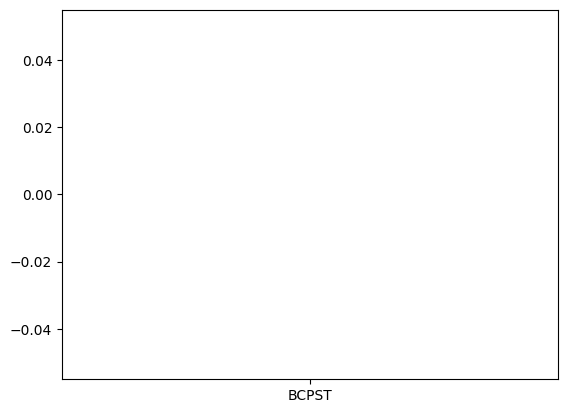

In [ ]:
# Classification
probas_test = NBClass(x_test)

# Plot of the results
plt.vlines(list_filiere, 0, probas_test, linewidth = 20)

**Question:** you should observe that something is wrong. What? How to fix that?

*Because BCPST has only one student, the estimated standard deviation of the grades is $0$, and therefore there is a division by $0$ in the evaluation of the Gaussian density. A possible fix consists in assuming that, for each mandatory course, the Gaussian variables withing each filiere actually have the same variance, and thus this variance may be estimated on the whole sample rather than within each filiere. This is similar to the distinction between LDA and QDA.*

We modify the construction of `param` as follows.

In [ ]:
for filiere in list_filiere:
  # List of indices of individuals of the training set in filiere
  indices = y_train.index[y_train==filiere]

  # Number of individuals in filiere
  param.loc[filiere,'eff'] = len(indices)

  # Continuous explanatory variables: mandatory courses
  for m in mandatory_courses:
    param.loc[filiere,'mu_'+m] = x_train.loc[indices,m].mean()
    param.loc[filiere,'sigma_'+m] = x_train[m].std(ddof=0)

  # Discrete explanatory variables: elective courses
  for e in list_electif:
    param.loc[filiere,'p_ELECTIF_'+e] = (x_train.loc[indices,'ELECTIF']==e).mean()

param

,eff,mu_MEDP,sigma_MEDP,mu_CALC,sigma_CALC,mu_OPTI,sigma_OPTI,mu_OMPM,sigma_OMPM,mu_ENRJ1,...,sigma_ISHS,mu_COMM,sigma_COMM,p_ELECTIF_IMET,p_ELECTIF_URBVI,p_ELECTIF_BIOGC,p_ELECTIF_PHEXT,p_ELECTIF_IMPAC,p_ELECTIF_DDIC,p_ELECTIF_ISCV
BCPST,1,15.4,2.599215,16.7,2.749433,11.1,2.625157,8.0,3.324662,10.0,...,2.174799,13.5,1.629275,1.0,0.0,0.0,0.0,0.0,0.0,0.0
MP,84,16.933333,2.599215,14.034524,2.749433,14.720238,2.625157,8.272619,3.324662,12.45,...,2.174799,16.045238,1.629275,0.154762,0.047619,0.083333,0.178571,0.154762,0.178571,0.202381
MPI,4,17.05,2.599215,14.15,2.749433,12.925,2.625157,5.95,3.324662,12.825,...,2.174799,15.125,1.629275,0.75,0.0,0.25,0.0,0.0,0.0,0.0
PC,37,15.597297,2.599215,13.935135,2.749433,13.637838,2.625157,8.737838,3.324662,12.081081,...,2.174799,16.102703,1.629275,0.081081,0.189189,0.162162,0.162162,0.135135,0.189189,0.081081
PSI,63,15.795238,2.599215,13.284127,2.749433,13.909524,2.625157,8.796825,3.324662,13.004762,...,2.174799,16.214286,1.629275,0.142857,0.206349,0.111111,0.126984,0.126984,0.190476,0.095238
PT,15,14.76,2.599215,11.46,2.749433,13.486667,2.625157,8.0,3.324662,10.493333,...,2.174799,15.326667,1.629275,0.133333,0.2,0.0,0.0,0.133333,0.266667,0.266667
AST,6,11.216667,2.599215,13.0,2.749433,11.283333,2.625157,4.216667,3.324662,8.066667,...,2.174799,17.566667,1.629275,0.0,0.5,0.0,0.0,0.333333,0.166667,0.0


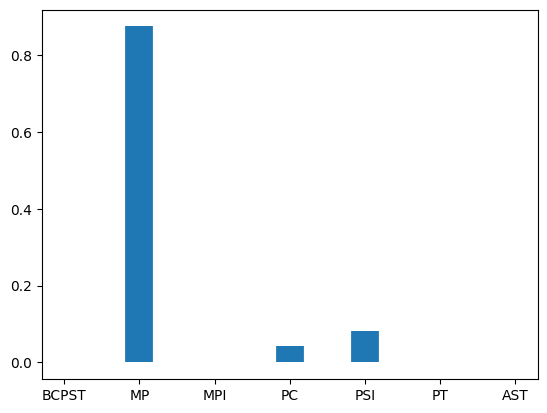

In [ ]:
# Classification
probas_test = NBClass(x_test)

# Plot of the results
plt.vlines(list_filiere, 0, probas_test, linewidth = 20)

### Confusion matrix and accuracy

Given a student with vector of features `x`, `NBClass(x)` returns the conditional probabilities that this student originates from each possible filiere. The predicted filiere for this student is therefore the filiere with largest conditional probability.

In [ ]:
# Predicted filiere with features x_test
probas_test.idxmax() # Returns the index of the maximum of the Series probas_test

'MP'

To assess the accuracy of this prediction, one may compute the predicted filiere of all students in the dataset, and present the results under the form of a confusion matrix: a two-dimensional array, whose rows and columns are indexed by `list_filiere`, such that the cell on the $i$-th and $j$-column contains the number of students whose true filiere is $i$ and whose predicted filiere is $j$. The larger the numbers on the diagonal of the confusion matrix, the better the prediction. In particular, one may define the global accuracy as the ratio between the trace of the confusion matrix and the total size of the sample: it is between $0$ and $1$ and gives the overall proportion of correct predictions.

**Question:** compute the confusion matrix and the global accuracy of naive Bayes classification.

In [ ]:
confusion_matrix = pd.DataFrame(0, index=list_filiere, columns=list_filiere)

for  i in range(n):
  true_y = dataset.loc[i,'FILIERE']
  x = dataset.loc[i,explanatory_variables]
  probas = NBClass(x)
  predicted_y = probas.idxmax()
  confusion_matrix.loc[true_y,predicted_y] += 1

confusion_matrix

,BCPST,MP,MPI,PC,PSI,PT,AST
BCPST,1,0,0,0,0,0,0
MP,0,72,0,0,10,2,0
MPI,0,3,0,0,1,0,0
PC,0,18,0,3,14,1,1
PSI,0,31,0,0,30,2,0
PT,0,5,0,1,5,4,0
AST,0,0,0,0,2,0,4


In [ ]:
print("Total accuracy:", sum(np.diag(confusion_matrix))/n)

Total accuracy: 0.5428571428571428


**Final remark:** in the procedure above, we have used the same dataset to estimate the parameters contained in the DataFrame `param`, and to test the accuracy of the classification. This is not a good practice: the dataset should always be separated between a training set, which is used to learn statistical properties of the data, and a test set on which the quality of the classification algorithm is evaluated. In the sequel of the course we will learn how to do this.